# **Anscombe's quartet: importance of visualizing data**

A famous set of four datasets created by statistician Francis Anscombe. 
Each dataset has nearly identical simple descriptive statistics (mean, variance, correlation, linear regression), 
but their distributions and plots look very different.

It demonstrates the importance of visualizing data, not just relying on summary statistics.

In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.core.reshape.pivot import pivot
from IPython.display import display
from IPython.display import display_html
from pandas.io.formats.style import Styler

## Load the built-in Anscombe dataset
def anscombe():
    """
    Load Anscombe's quartet dataset.
    
    Returns:
        DataFrame: A pandas DataFrame containing the Anscombe's quartet data.
    """
    return sns.load_dataset("anscombe")
df = anscombe()
df.head(44)

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33
5,I,14.0,9.96
6,I,6.0,7.24
7,I,4.0,4.26
8,I,12.0,10.84
9,I,7.0,4.82


## Pivot so top-level columns are datasets, subcolumns are x/y

In [44]:
## Pivot so top-level columns are datasets, subcolumns are x/y
# plan to show the raw data and the stats later

# Add a row number if not present
df = df.copy()
df['observation'] = df.groupby('dataset').cumcount()

# Pivot so top-level columns are datasets, subcolumns are x/y
df_wide = df.pivot(index='observation', columns='dataset', values=['x', 'y'])

# Optional: tidy up column order
df_wide = df_wide.swaplevel(axis=1).sort_index(axis=1, level=0)

# Reset index to remove 'observation' as the row label
df_wide_reset = df_wide.reset_index(drop=True)

# Display without the observation header column
# Display the DataFrame without the index (row numbers)
# Format x to 1 decimal and y to 2 decimals for all datasets

def custom_format(val, col_name):
    if col_name[1] == 'x':
        return f"{val:.1f}"
    elif col_name[1] == 'y':
        return f"{val:.2f}"
    return val

display(
    df_wide_reset.head(10)
    .style
    .hide(axis="index")
    .format({col: (lambda v, c=col: custom_format(v, c)) for col in df_wide_reset.columns})
)

## Show the stats: Compute mean, std, variance, and correlation for x and y in each dataset

In [45]:
# Show the stats
# Compute mean, std, variance, and correlation for x and y in each dataset

result = []

for d in ['I', 'II', 'III', 'IV']:
    data = df[df['dataset'] == d]
    mean_x = data['x'].mean()
    mean_y = data['y'].mean()
    std_x = data['x'].std()
    std_y = data['y'].std()
    var_x = data['x'].var()
    var_y = data['y'].var()
    corr = data['x'].corr(data['y'])
    result.append({
        'Dataset': d,
        'mean_x': round(mean_x, 2),
        'std_x': round(std_x, 2),
        'var_x': round(var_x, 2),
        'mean_y': round(mean_y, 2),
        'std_y': round(std_y, 2),
        'var_y': round(var_y, 2),
        'corr(x, y)': round(corr, 3)
    })

pd.DataFrame(result).set_index('Dataset')


,mean_x,std_x,var_x,mean_y,std_y,var_y,"corr(x, y)"
Dataset,,,,,,,
I,9.0,3.32,11.0,7.5,2.03,4.13,0.816
II,9.0,3.32,11.0,7.5,2.03,4.13,0.816
III,9.0,3.32,11.0,7.5,2.03,4.12,0.816
IV,9.0,3.32,11.0,7.5,2.03,4.12,0.817


## Display both tables side by side

In [46]:
table1 = df_wide_reset.head(10)
table2 = pd.DataFrame(result).set_index('Dataset')

table1_html = table1.to_html()
table2_html = table2.to_html()

display_html(f'<div style="display:flex;gap:40px;">{table1_html}{table2_html}</div>', raw=True)


dataset 
 I 
 II 
 III 
 IV 
 
 
 
 x 
 y 
 x 
 y 
 x 
 y 
 x 
 y 
 
 
 
 
 0 
 10.0 
 8.04 
 10.0 
 9.14 
 10.0 
 7.46 
 8.0 
 6.58 
 
 
 1 
 8.0 
 6.95 
 8.0 
 8.14 
 8.0 
 6.77 
 8.0 
 5.76 
 
 
 2 
 13.0 
 7.58 
 13.0 
 8.74 
 13.0 
 12.74 
 8.0 
 7.71 
 
 
 3 
 9.0 
 8.81 
 9.0 
 8.77 
 9.0 
 7.11 
 8.0 
 8.84 
 
 
 4 
 11.0 
 8.33 
 11.0 
 9.26 
 11.0 
 7.81 
 8.0 
 8.47 
 
 
 5 
 14.0 
 9.96 
 14.0 
 8.10 
 14.0 
 8.84 
 8.0 
 7.04 
 
 
 6 
 6.0 
 7.24 
 6.0 
 6.13 
 6.0 
 6.08 
 8.0 
 5.25 
 
 
 7 
 4.0 
 4.26 
 4.0 
 3.10 
 4.0 
 5.39 
 19.0 
 12.50 
 
 
 8 
 12.0 
 10.84 
 12.0 
 9.13 
 12.0 
 8.15 
 8.0 
 5.56 
 
 
 9 
 7.0 
 4.82 
 7.0 
 7.26 
 7.0 
 6.42 
 8.0 
 7.91 
 
 
 
 
 
 
 mean_x 
 std_x 
 var_x 
 mean_y 
 std_y 
 var_y 
 corr(x, y) 
 
 
 Dataset 
 
 
 
 
 
 
 
 
 
 
 
 I 
 9.0 
 3.32 
 11.0 
 7.5 
 2.03 
 4.13 
 0.816 
 
 
 II 
 9.0 
 3.32 
 11.0 
 7.5 
 2.03 
 4.13 
 0.816 
 
 
 III 
 9.0 
 3.32 
 11.0 
 7.5 
 2.03 
 4.12 
 0.816 
 
 
 IV 
 9.0 
 3.32 
 11.0 
 7.5 
 2.03 
 4.12 
 0.817

## Now visualize the data! Create a 2x2 grid of subplots

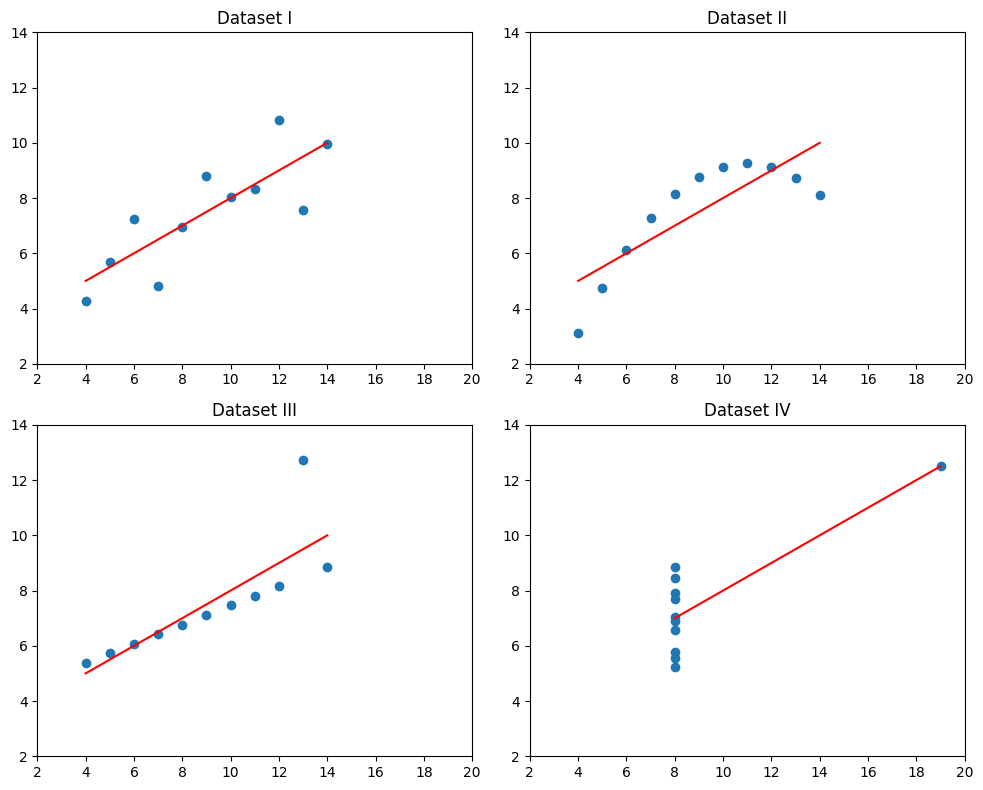

In [47]:
# Create a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.flatten()

# Dataset names
datasets = ['I', 'II', 'III', 'IV']
# Plot each dataset in each subplot
for i, dataset in enumerate(datasets):
    data = df[df['dataset'] == dataset]
    axs[i].scatter(data['x'], data['y'])
    # Fit line
    m, c = np.polyfit(data['x'], data['y'], 1)
    x_vals = np.array([data['x'].min(), data['x'].max()])
    axs[i].plot(x_vals, m * x_vals + c, color='red')
    axs[i].set_title(f'Dataset {dataset}')
    axs[i].set_xlim(2, 20)
    axs[i].set_ylim(2, 14)

plt.tight_layout()
plt.show()